In [1]:
import os
import sys
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm

SCRIPT_DIR = os.path.dirname(os.path.realpath(os.path.join(os.path.dirname(os.getcwd()))))
sys.path.append(SCRIPT_DIR)

import gwfast.gwfastGlobals as glob
import gwfast.waveforms as waveforms
import gwfast.signal as signal
import gwfast.network as network
import gwfast.fisherTools as fTools
import gwfast.gwfastUtils as utils

LSC Algorithm Library (LAL) is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH
TEOBResumS is not installed, only the GWFAST waveform models are available, namely: TaylorF2, IMRPhenomD, IMRPhenomD_NRTidalv2, IMRPhenomHM and IMRPhenomNSBH


## Parameters, waveform, and detector setup

In [2]:
events = {
    'Mc':np.array([30, 30]), 'eta':np.array([0.24, 0.24]), 'dL':np.array([2, 2]), 'theta':np.array([2.34, 2.34]), 'phi':np.array([5.43, 5.43]), 
    'iota':np.array([0.99*np.pi/2, 0.99*np.pi/2]), 'psi':np.array([1, 1]), 'tcoal':np.array([0, 0]), 'Phicoal':np.array([2, 2]), 
    'chiS':np.array([0.5, 0.7]), 'chiA':np.array([0.5, 0.7]), 'chi1x':np.array([0, 0]), 'chi2x':np.array([0, 0]), 'chi1y':np.array([0, 0]), 'chi2y':np.array([0, 0]), 
    'LambdaTilde':np.array([0, 0]), 'deltaLambda':np.array([0, 0]), 'ecc':np.array([0, 0]), 
    'R_orbit':np.array([200, 200]), 'M_lens':np.array([1e4, 1e4]), 'src_pos':np.array([0.7, 0.7])
}

# Using TaylorF2 for now to speed things up
mywf = waveforms.IMRPhenomD()

In [3]:
# Overview of lensing effects
utils.lens(events)

Image 1 parameters: {'Mc': Array([29.66473305, 29.66473305], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([2, 2]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.52741231, 1.52741231], dtype=float64), 'psi': Array([1.00150888, 1.00150888], dtype=float64), 'tcoal': array([0, 0]), 'Phicoal': Array([1.90578199, 1.90578199], dtype=float64), 'chiS': array([0.5, 0.7]), 'chiA': array([0.5, 0.7]), 'chi1x': array([0, 0]), 'chi2x': array([0, 0]), 'chi1y': array([0, 0]), 'chi2y': array([0, 0]), 'LambdaTilde': array([0, 0]), 'deltaLambda': array([0, 0]), 'ecc': array([0, 0]), 'R_orbit': array([200, 200]), 'M_lens': array([10000., 10000.]), 'src_pos': array([0.7, 0.7])} 
Image 2 parameters: {'Mc': Array([30.34146809, 30.34146809], dtype=float64), 'eta': array([0.24, 0.24]), 'dL': array([2, 2]), 'theta': array([2.34, 2.34]), 'phi': array([5.43, 5.43]), 'iota': Array([1.58275239, 1.58275239], dtype=float64), 'psi': Array([0.99848966, 0.99848966], dtype=float64),

In [4]:
# Detector configurations
L1_conf = copy.deepcopy(glob.detectors).pop('L1')
L1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

H1_conf = copy.deepcopy(glob.detectors).pop('H1')
H1_conf['psd_path'] = os.path.join(glob.detPath, 'observing_scenarios_paper', 'AplusDesign.txt')

Virgo_conf = copy.deepcopy(glob.detectors).pop('Virgo')
Virgo_conf['psd_path'] =  os.path.join(glob.detPath, 'observing_scenarios_paper', 'avirgo_O5low_NEW.txt')

# Initialise the GWSignal objects
L1 = signal.GWSignal(mywf, psd_path=L1_conf['psd_path'], 
                        detector_shape=L1_conf['shape'], det_lat=L1_conf['lat'], 
                        det_long=L1_conf['long'], det_xax=L1_conf['xax'],
                        fmin=10
                        )
H1 = signal.GWSignal(mywf, psd_path=H1_conf['psd_path'], 
                        detector_shape=H1_conf['shape'], det_lat=H1_conf['lat'], 
                        det_long=H1_conf['long'], det_xax=H1_conf['xax'],
                        fmin=10
                        )
Virgo = signal.GWSignal(mywf, psd_path=Virgo_conf['psd_path'], 
                        detector_shape=Virgo_conf['shape'], det_lat=Virgo_conf['lat'], 
                        det_long=Virgo_conf['long'], det_xax=Virgo_conf['xax'],
                        fmin=10
                        )

mySignals = {'L1':L1, 'H1':H1, 'Virgo':Virgo}
myNet = network.DetNet(mySignals)

Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/AplusDesign.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8
Using ASD from file /Users/yuranzhang/gwfast_AGN/gwfast_moddd/psds/observing_scenarios_paper/avirgo_O5low_NEW.txt 
Initializing jax...
Jax local device count: 8
Jax  device count: 8


In [5]:
# Select event
ev = 0

## Strain

In [16]:
# Prepare frequency domain data
f_array = np.geomspace(10, 512, num=500)
strain = L1.GWstrain(f_array, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chiS'][ev], events['chiA'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=True)
strain_unlensed = L1.GWstrain(f_array, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chiS'][ev], events['chiA'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=False)

In [32]:
# Prepare time domain data
min_f = 10
duration = 4 # s
sampling_frequency = 1024. #Hz
delta_f = 1/ duration
f_array_lin = np.arange(min_f, sampling_frequency/2, delta_f)

strain_lin = L1.GWstrain(f_array_lin, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chiS'][ev], events['chiA'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=True)
strain_unlensed_lin = L1.GWstrain(f_array_lin, events['Mc'][ev], events['eta'][ev], events['dL'][ev], events['theta'][ev], events['phi'][ev], events['iota'][ev], 
                       events['psi'][ev], events['tcoal'][ev], events['Phicoal'][ev], events['chiS'][ev], events['chiA'][ev], 
                       events['chi1x'][ev], events['chi2x'][ev], events['chi1y'][ev], events['chi2y'][ev], events['LambdaTilde'][ev], events['deltaLambda'][ev], events['ecc'][ev], 
                       R_orbit=events['R_orbit'][ev], M_lens=events['M_lens'][ev], src_pos=events['src_pos'][ev], use_lensing=False)

prepend = np.zeros(int(min_f / delta_f))
padded_strain_lin = np.hstack([prepend, strain_lin])
padded_strain_unlensed_lin = np.hstack([prepend, strain_unlensed_lin])

strain_t = np.fft.irfft(padded_strain_lin)
strain_unlensed_t = np.fft.irfft(padded_strain_unlensed_lin)

t_array = np.arange(len(strain_t)) / sampling_frequency

# Wrap ringdown to the end
post_merger_time = -0.05
n_index = int(post_merger_time * sampling_frequency)
strain_t_shifted = np.roll(strain_t, n_index)
strain_unlensed_t_shifted = np.roll(strain_unlensed_t, n_index)

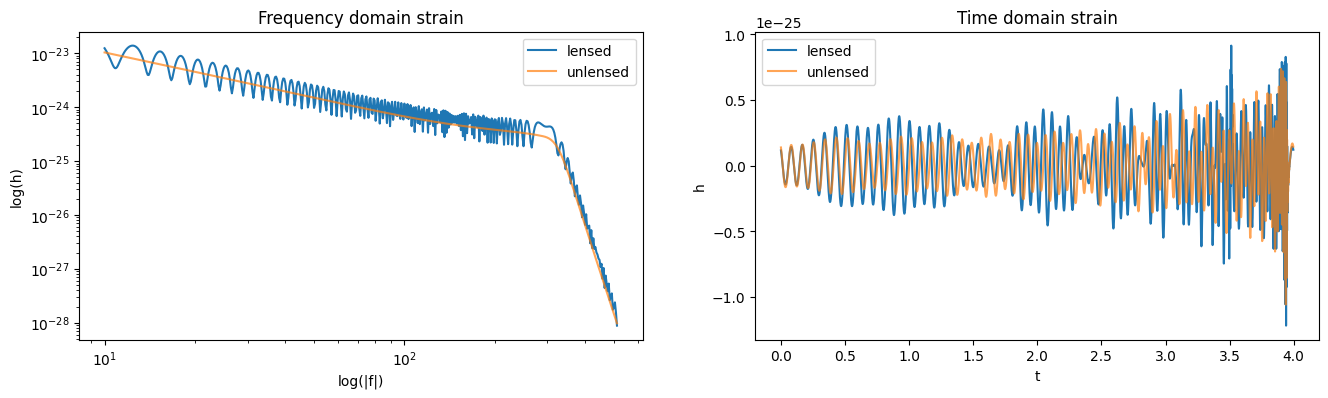

In [33]:
fig, axs = plt.subplots(1, 2, figsize=(16,4))

axs[0].loglog(f_array, np.abs(strain), label='lensed')
axs[0].loglog(f_array, np.abs(strain_unlensed), alpha=0.7, label='unlensed')
axs[0].set_title('Frequency domain strain')
axs[0].set_xlabel('log(|f|)')
axs[0].set_ylabel('log(h)')
axs[0].legend()

axs[1].plot(t_array, strain_t_shifted.real, label='lensed')
axs[1].plot(t_array, strain_unlensed_t_shifted.real, alpha=0.7, label='unlensed')
axs[1].set_title('Time domain strain')
axs[1].set_xlabel('t')
axs[1].set_ylabel('h')
axs[1].legend()

## SNR

In [9]:
mySNR = myNet.SNR(events, use_lensing=True, return_all=True)
mySNR_nolens = myNet.SNR(events, return_all=True)
print("SNR with lensing:", mySNR)
print("SNR without lensing:", mySNR_nolens)

Adding chi1z, chi2z from chiS, chiA
SNR with lensing: {'L1': Array([18.61726072, 19.61520528], dtype=float64), 'H1': Array([17.74485708, 18.74793185], dtype=float64), 'Virgo': Array([7.17455474, 7.56665851], dtype=float64), 'net': array([26.70124689, 28.16905302])}
SNR without lensing: {'L1': Array([10.09990621, 11.14005433], dtype=float64), 'H1': Array([ 9.50813   , 10.48726885], dtype=float64), 'Virgo': Array([3.85836204, 4.27567847], dtype=float64), 'net': array([14.3979026 , 15.88600153])}


## Fisher

In [10]:
# Fisher matrix (3-detector network) with lensing
FisherMatrsNet = myNet.FisherMatr(events, use_lensing=True)
# Group internal and external parameters together
order = [0, 1, 7, 8, 9, 10, 11, 12, 13, 2, 3, 4, 5, 6]
FisherMatrsNet = FisherMatrsNet[np.ix_(order, order)]
param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)

Computing Fisher for L1...
Computing derivatives...
Computing Fisher for H1...
Computing derivatives...
Computing Fisher for Virgo...
Computing derivatives...
Done.


In [11]:
FisherMatrsNet[:,3,0]

array([ 3.57595757e+03,  1.68414639e+05, -2.66788679e+05,  3.54706275e+02,
       -1.41995470e+04, -6.32278568e+03,  3.79874637e+00,  3.70030556e-01,
        5.39752573e+03,  8.20668126e+01, -4.24612102e+03, -2.04834230e+03,
       -4.37965457e+03,  5.47184446e+01])

Text(0.5, 1.0, 'Rescaled Fisher matrix')

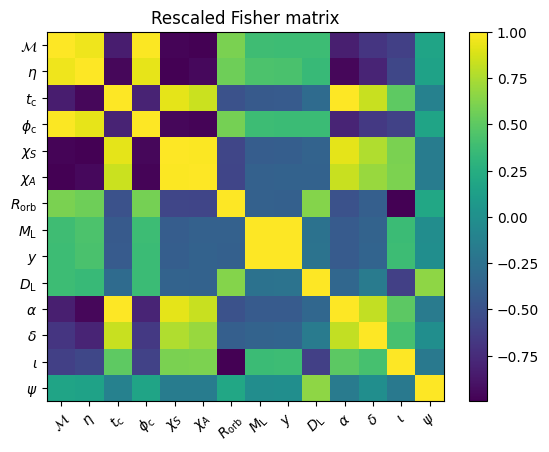

In [12]:
# Plot Fisher matrix
matrix = FisherMatrsNet[:, :, ev]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Rescaled Fisher matrix')

In [13]:
# Get covariance matrix and inversion error
Cov, ie = fTools.CovMatr(FisherMatrsNet)

std = np.sqrt(np.diag(Cov[:,:,ev]))
params = ['Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'alpha', 'delta', 'iota', 'psi']
print("Standard deviations:", ['{}: {:.6f}'.format(params[i], std[i]) for i in range(len(params))])
print("Inversion error:", ie)

Standard deviations: ['Mc: 0.110482', 'eta: 0.007480', 'tcoal: 0.003582', 'Phicoal: 0.409646', 'chiS: 0.170107', 'chiA: 0.318937', 'R_orbit: 46.113650', 'M_lens: 2046.853417', 'src_pos: 0.137912', 'dL: 0.210359', 'alpha: 0.053422', 'delta: 0.011307', 'iota: 0.041072', 'psi: 0.085542']
Inversion error: [2.32158232e-07 3.35995324e-07]


In [14]:
# Calculate fractional uncertainty
# For angular parameters, this is calculated as std / length of interval of possible values (2pi for Phicoal, alpha and psi, pi for delta and iota)
# For normalized parameters, this is taken as std (eta, src_pos)
# For all other parameters, this is calculated as std / injected value

scale_factor = [events['Mc'][ev], 1, events['tcoal'][ev], 2*np.pi, events['chiS'][ev], events['chiA'][ev], 
                events['R_orbit'][ev], events['M_lens'][ev], 1, 
                events['dL'][ev], 2*np.pi, np.pi, np.pi, 2*np.pi]
fractional_uncertainty = std / scale_factor
fractional_uncertainty

/var/folders/b4/hg5l8r9915b4cr385qb8sfdw0000gn/T/ipykernel_59650/3412555815.py:9: RuntimeWarning: divide by zero encountered in divide
  fractional_uncertainty = std / scale_factor


array([0.00368273, 0.00747969,        inf, 0.06519725, 0.34021451,
       0.63787398, 0.23056825, 0.20468534, 0.13791244, 0.10517936,
       0.00850245, 0.00359908, 0.01307362, 0.01361448], dtype=float128)

Text(0.5, 1.0, 'Correlation matrix')

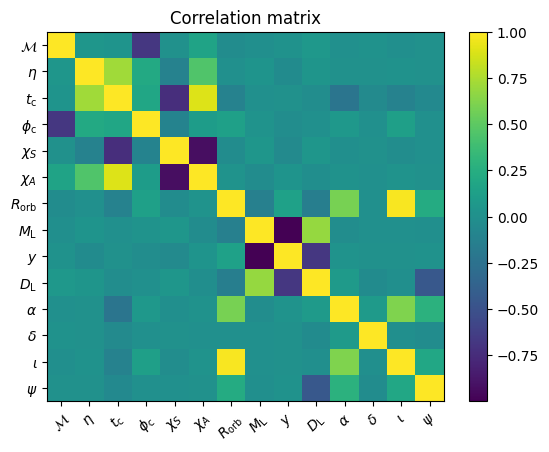

In [15]:
# Plot correlation coefficients
matrix = Cov[:, :, ev]
sqrt_diagonal = np.sqrt(np.diag(matrix))
sqrt_diagonal_inv = np.diag(1 / sqrt_diagonal)
matrix_rescaled = sqrt_diagonal_inv @ matrix @ sqrt_diagonal_inv

param_labels = (r'${\cal M}$', r'$\eta$', r'$t_{\rm c}$', r'$\phi_{\rm c}$',
    r'$\chi_{S}$', r'$\chi_{A}$', r'$R_{\rm orb}$', r'$M_{\rm L}$', r'$y$',
    r'$D_{\rm L}$', r'$\alpha$', r'$\delta$', r'$\iota$', r'$\psi$'
)
fig, ax = plt.subplots()
x = np.arange(0, matrix_rescaled.shape[0]+1, 1)
y = np.arange(matrix_rescaled.shape[1], -1, -1)
im = ax.pcolormesh(x, y, matrix_rescaled)
fig.colorbar(im)
ax.set_xticks(np.arange(0, matrix_rescaled.shape[0], 1)+0.5, param_labels, rotation=45)
ax.set_yticks(np.arange(matrix_rescaled.shape[1], 0, -1)-0.5, param_labels)
ax.set_title('Correlation matrix')

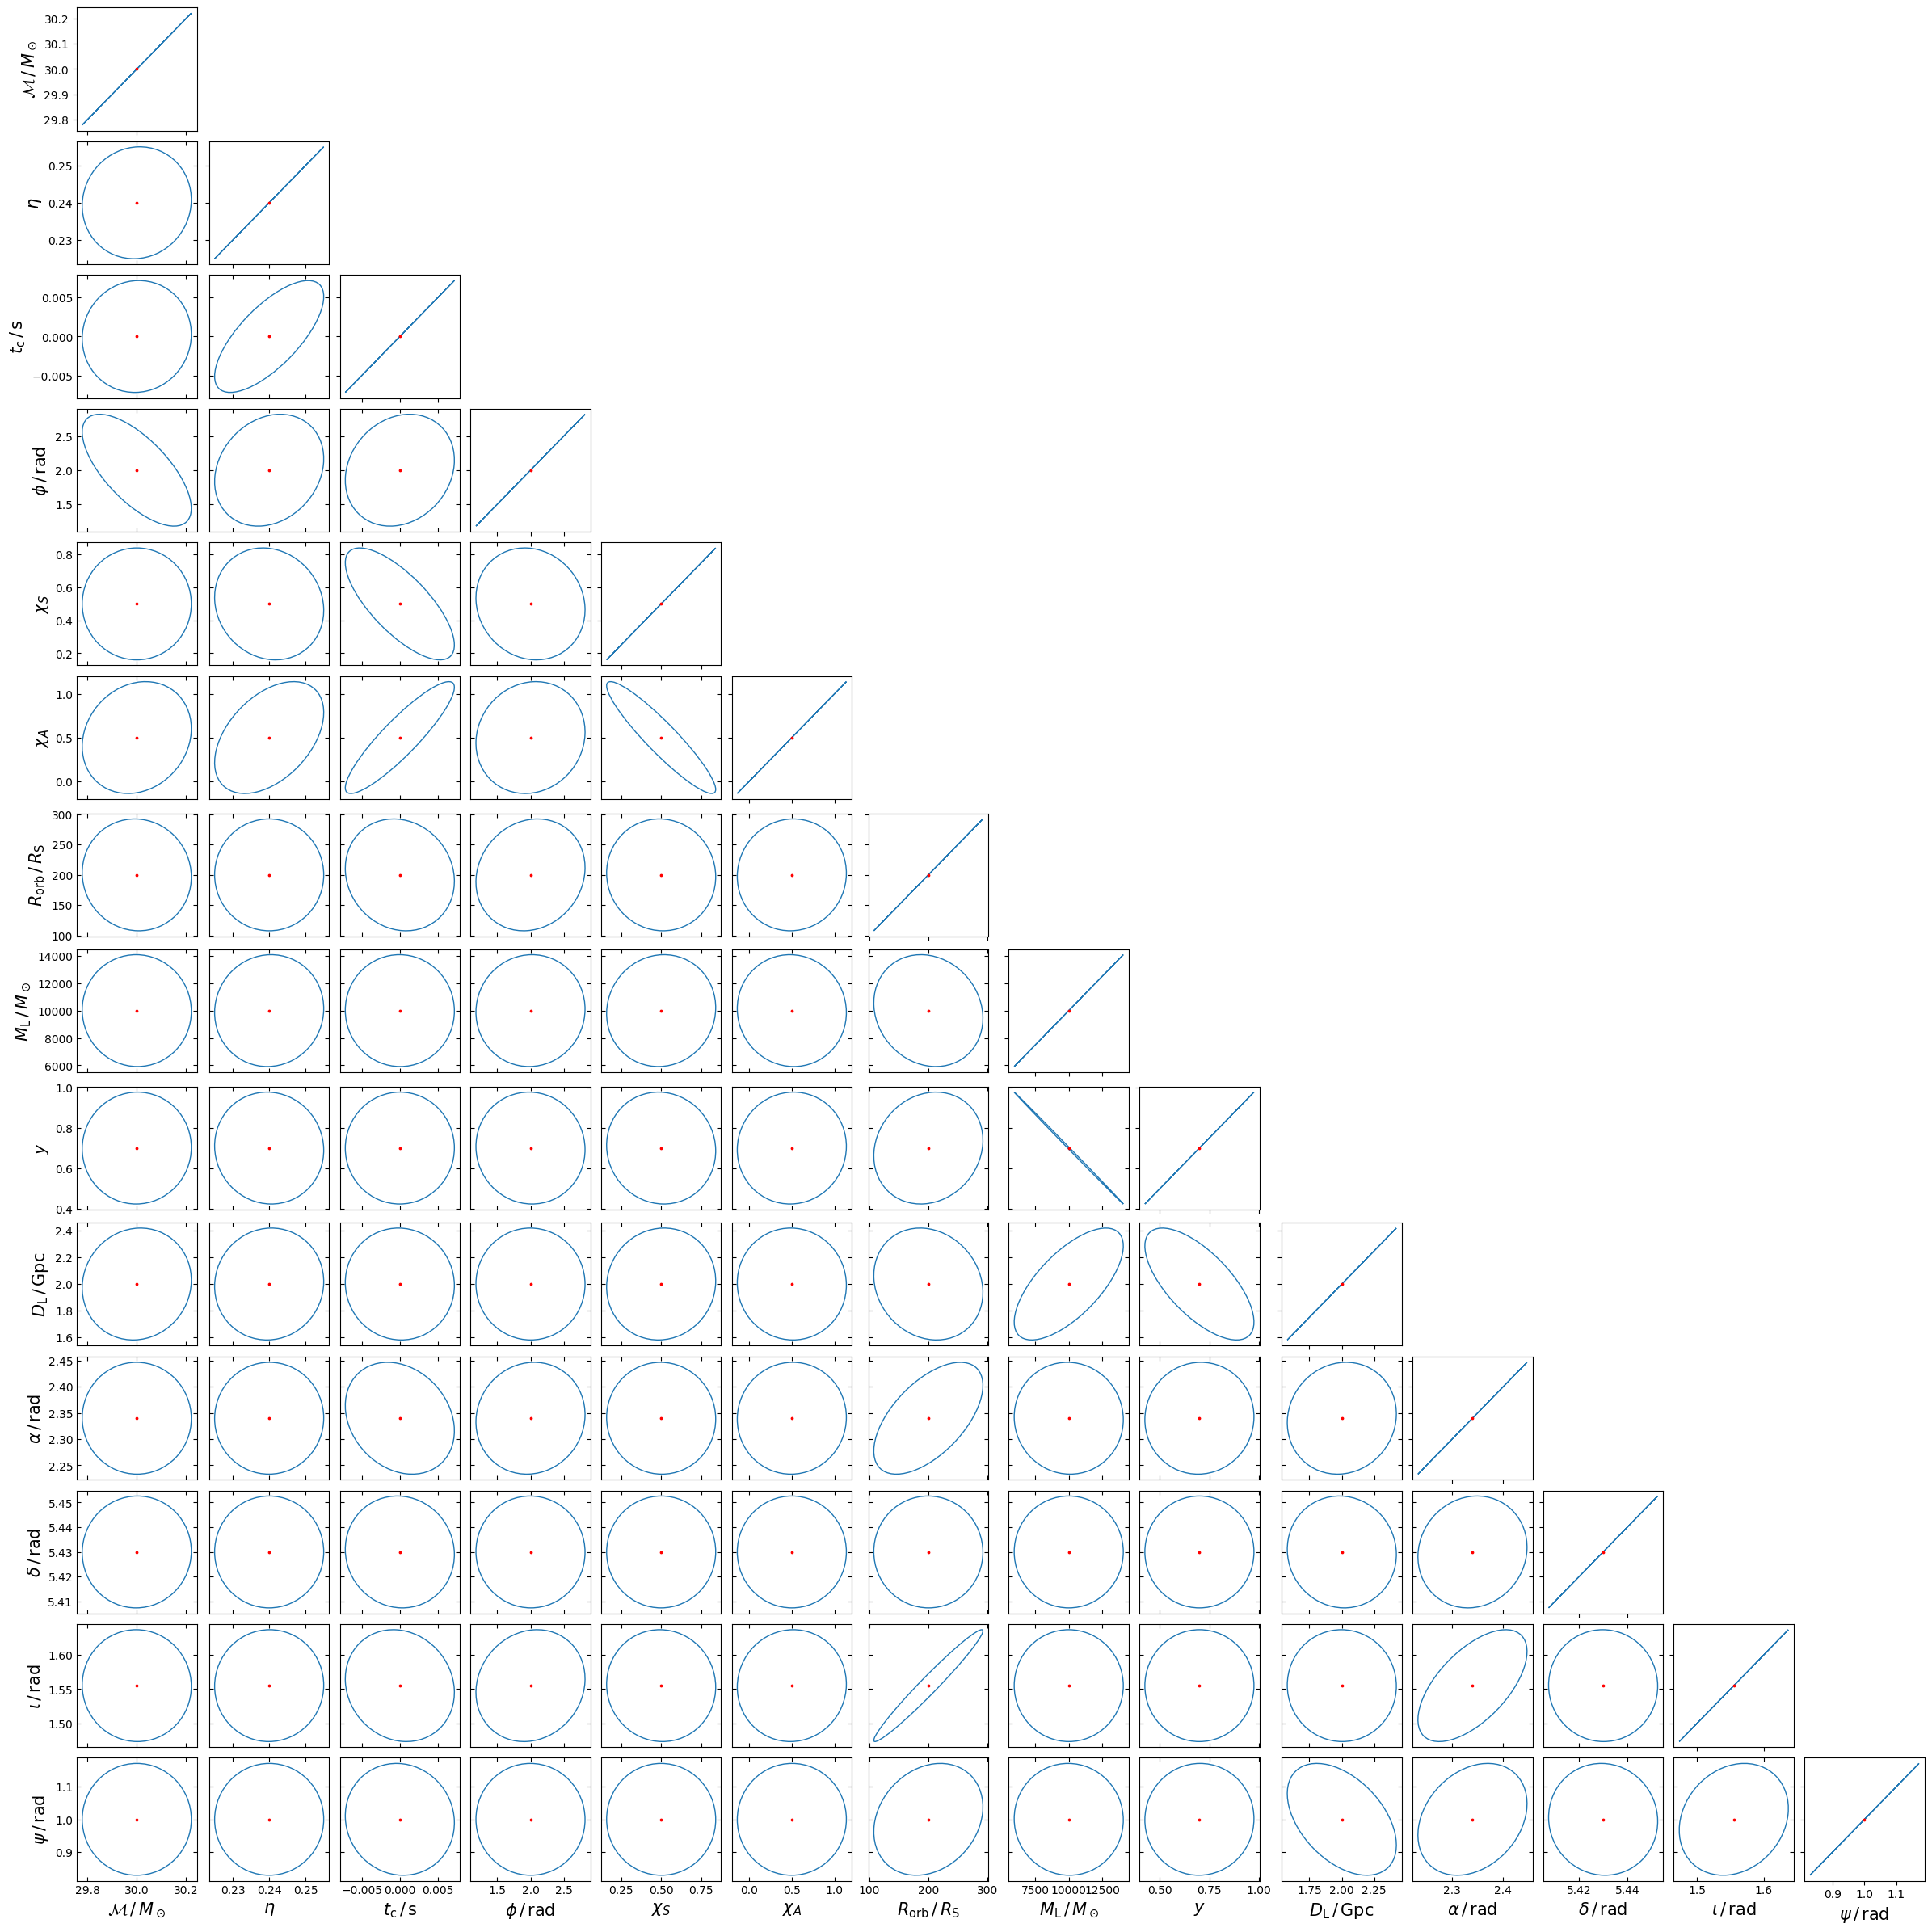

In [16]:
params = ('Mc', 'eta', 'tcoal', 'Phicoal', 'chiS', 'chiA', 'R_orbit', 'M_lens', 'src_pos', 'dL', 'theta', 'phi', 'iota', 'psi')
# We rearranged the list of parameters, so the indices needs to be updated accordingly
indices = np.arange(0, 14)

labels = {
    'Mc': r'${\cal M}\,/\,M_\odot$',
    'eta': r'$\eta$',
    'dL': r'$D_{\rm L}\,/\,{\rm Gpc}$',
    'theta': r'$\alpha\,/\,{\rm rad}$',
    'phi': r'$\delta\,/\,{\rm rad}$',
    'iota': r'$\iota\,/\,{\rm rad}$',
    'psi': r'$\psi\,/\,{\rm rad}$',
    'tcoal': r'$t_{\rm c}\,/\,{\rm s}$',
    'Phicoal': r'$\phi\,/\,{\rm rad}$',
    'chiS': r'$\chi_{S}$',
    'chiA': r'$\chi_{A}$',
    'R_orbit': r'$R_{\rm orb}\,/\,R_{\rm S}$',
    'M_lens': r'$M_{\rm L}\,/\,M_\odot$',
    'src_pos': r'$y$'
}

event = {key: val[0] for key, val in events.items()}

fig = fTools.plot_corners(
    Cov[:, :, ev], params, indices, 
    event=event, labels=labels, color='C0'
)

fig.savefig('test_Fisher_matrix.png', dpi=200)